# 🃏 BlackjackVAI — Entrenamiento Local v3

**Modelo:** YOLOv8m-seg (segmentación de instancias)  
**Dataset:** BlackjackVAI V3 — color, sin grayscale, sin tiling, 80/10/10 split  
**GPU:** Local (RTX 4070 Laptop / cualquier CUDA)  
**Tracking:** MLflow  

### Características
- Reanuda automáticamente si el entreno se interrumpe (`RESUME = True`)
- Checkpoints cada 10 epochs + best/last siempre guardados
- MLflow loggea métricas, hiperparámetros y artefactos por epoch
- El modelo final se copia a `models/best.pt`

### Cómo reanudar el entreno
Si se corta el entrenamiento, simplemente vuelve a ejecutar todas las celdas con `RESUME = True` (valor por defecto). Detectará `last.pt` automáticamente.

## 0. Configuración — edita aquí antes de ejecutar

In [1]:
# ── CONFIGURACIÓN PRINCIPAL ────────────────────────────────────────────────────
import os
from dotenv import load_dotenv

load_dotenv()

# MLflow — setear ANTES de importar ultralytics
MLFLOW_EXPERIMENT = "blackjackvai-v3"
os.environ["MLFLOW_TRACKING_URI"]    = "http://172.31.71.204:5001"
os.environ["MLFLOW_EXPERIMENT_NAME"] = MLFLOW_EXPERIMENT  # nombre correcto para YOLO

# Roboflow
ROBOFLOW_API_KEY   = os.environ["ROBOFLOW_API_KEY"]
ROBOFLOW_WORKSPACE = "javiers-workspace-q8mnr"
ROBOFLOW_PROJECT   = "blackjackvai"
ROBOFLOW_VERSION   = 3

from pathlib import Path
BASE_DIR    = Path(".").resolve()   # ruta absoluta — evita que YOLO añada runs/segment/
DATASET_DIR = BASE_DIR / f"BlackjackVAI-{ROBOFLOW_VERSION}"
WORKDIR     = BASE_DIR / "training_runs"
MODELS_DIR  = BASE_DIR / "models"

RUN_NAME    = "yolo8m_seg_v3"
MODEL_BASE  = "yolov8m-seg.pt"
EPOCHS      = 100
IMGSZ       = 640
BATCH       = 8
PATIENCE    = 20
SEED        = 42
SAVE_PERIOD = 10
RESUME      = True

DATA_YAML = DATASET_DIR / "data.yaml"
RUN_DIR   = WORKDIR / "runs" / RUN_NAME          # ruta real donde YOLO guardará
BEST_PT   = RUN_DIR / "weights" / "best.pt"
LAST_PT   = RUN_DIR / "weights" / "last.pt"

WORKDIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset dir         : {DATASET_DIR}")
print(f"Run dir             : {RUN_DIR}")
print(f"MLflow URI          : {os.environ['MLFLOW_TRACKING_URI']}")
print(f"MLflow experiment   : {MLFLOW_EXPERIMENT}")
print(f"Resume              : {RESUME}")

Dataset dir         : /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-3
Run dir             : /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/training_runs/runs/yolo8m_seg_v3
MLflow URI          : http://172.31.71.204:5001
MLflow experiment   : blackjackvai-v3
Resume              : True


## 1. Dependencias y verificación de GPU

In [2]:
import torch

DEVICE = 0 if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    vram_gb = gpu.total_memory / 1e9
    print(f"GPU : {gpu.name}  |  VRAM: {vram_gb:.1f} GB")
    if vram_gb < 6:
        print("AVISO: menos de 6 GB VRAM — considera BATCH=4 o MODEL_BASE=yolov8s-seg.pt")
else:
    print("AVISO: no se detectó GPU — el entreno será muy lento en CPU")

import ultralytics, mlflow
print(f"Ultralytics {ultralytics.__version__} | MLflow {mlflow.__version__} | PyTorch {torch.__version__}")

# Si falta algún paquete, instálalo con:
#   uv pip install ultralytics roboflow mlflow pyyaml python-dotenv
# o: pip install ultralytics roboflow mlflow pyyaml python-dotenv

GPU : NVIDIA GeForce RTX 4070 Laptop GPU  |  VRAM: 8.6 GB


/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/pydantic/_internal/_fields.py:160: UserWarning: Field "model_name" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
/home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ultralytics 8.4.45 | MLflow 3.10.0 | PyTorch 2.10.0+cu128


## 2. Descarga del dataset (omite si ya está descargado)

In [3]:
if DATA_YAML.exists():
    print(f"Dataset ya existe en {DATASET_DIR} — saltando descarga.")
else:
    print("Descargando dataset desde Roboflow...")
    from roboflow import Roboflow
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
    dataset = project.version(ROBOFLOW_VERSION).download("yolov8", location=str(DATASET_DIR))
    print(f"Dataset descargado en: {dataset.location}")

Dataset ya existe en /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-3 — saltando descarga.


## 3. Preparar data.yaml

In [4]:
import yaml, shutil

with open(DATA_YAML) as f:
    data = yaml.safe_load(f)

# Fijar ruta absoluta al dataset
data["path"] = str(DATASET_DIR.resolve())

# Normalizar 'valid' → 'val' (convención Roboflow vs YOLO)
for key in list(data.keys()):
    if key == "valid":
        val = data.pop(key)
        data["val"] = str(val).replace("valid/", "val/").replace("/valid/", "/val/")

# Renombrar carpeta en disco si hace falta
valid_dir = DATASET_DIR / "valid"
val_dir   = DATASET_DIR / "val"
if valid_dir.exists() and not val_dir.exists():
    shutil.copytree(valid_dir, val_dir)
    print("Carpeta 'valid' copiada a 'val'")

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False, allow_unicode=True)

names = data["names"] if isinstance(data["names"], list) else list(data["names"].values())
print(f"Clases ({data['nc']}): {names[:8]} ...")

for split in ["train", "val", "test"]:
    img_dir = DATASET_DIR / split / "images"
    if img_dir.exists():
        n = len(list(img_dir.glob("*.*")))
        print(f"  {split}: {n} imágenes")

Clases (54): ['10 Clubs', '10 Diamonds', '10 Hearts', '10 Spades', '2 Clubs', '2 Diamonds', '2 Hearts', '2 Spades'] ...
  train: 2564 imágenes
  val: 314 imágenes
  test: 314 imágenes


## 4. Limpiar etiquetas mixtas detect/segment

In [5]:
def fix_labels(label_dir: Path) -> int:
    n_fixed = 0
    for lbl in label_dir.glob("*.txt"):
        lines = lbl.read_text(encoding="utf-8").splitlines()
        seg_lines = [
            ln for ln in lines
            if ln.strip() and
               len(ln.strip().split()) > 5 and
               (len(ln.strip().split()) - 1) % 2 == 0
        ]
        if len(seg_lines) != len([l for l in lines if l.strip()]):
            lbl.write_text("\n".join(seg_lines), encoding="utf-8")
            n_fixed += 1
    return n_fixed

for split in ["train", "val", "test"]:
    lbl_dir = DATASET_DIR / split / "labels"
    if lbl_dir.exists():
        n = fix_labels(lbl_dir)
        print(f"{split}: {n} ficheros corregidos")

# Borrar caches viejas
for cache in DATASET_DIR.rglob("*.cache"):
    cache.unlink()
    print(f"Cache eliminada: {cache}")

print("Labels OK.")

train: 0 ficheros corregidos
val: 0 ficheros corregidos
test: 0 ficheros corregidos
Cache eliminada: /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-3/valid/labels.cache
Cache eliminada: /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-3/train/labels.cache
Labels OK.


## 5. Visualización del dataset (9 muestras)

/tmp/ipykernel_2928/3504326452.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  CMAP = plt.cm.get_cmap("tab20", len(names))


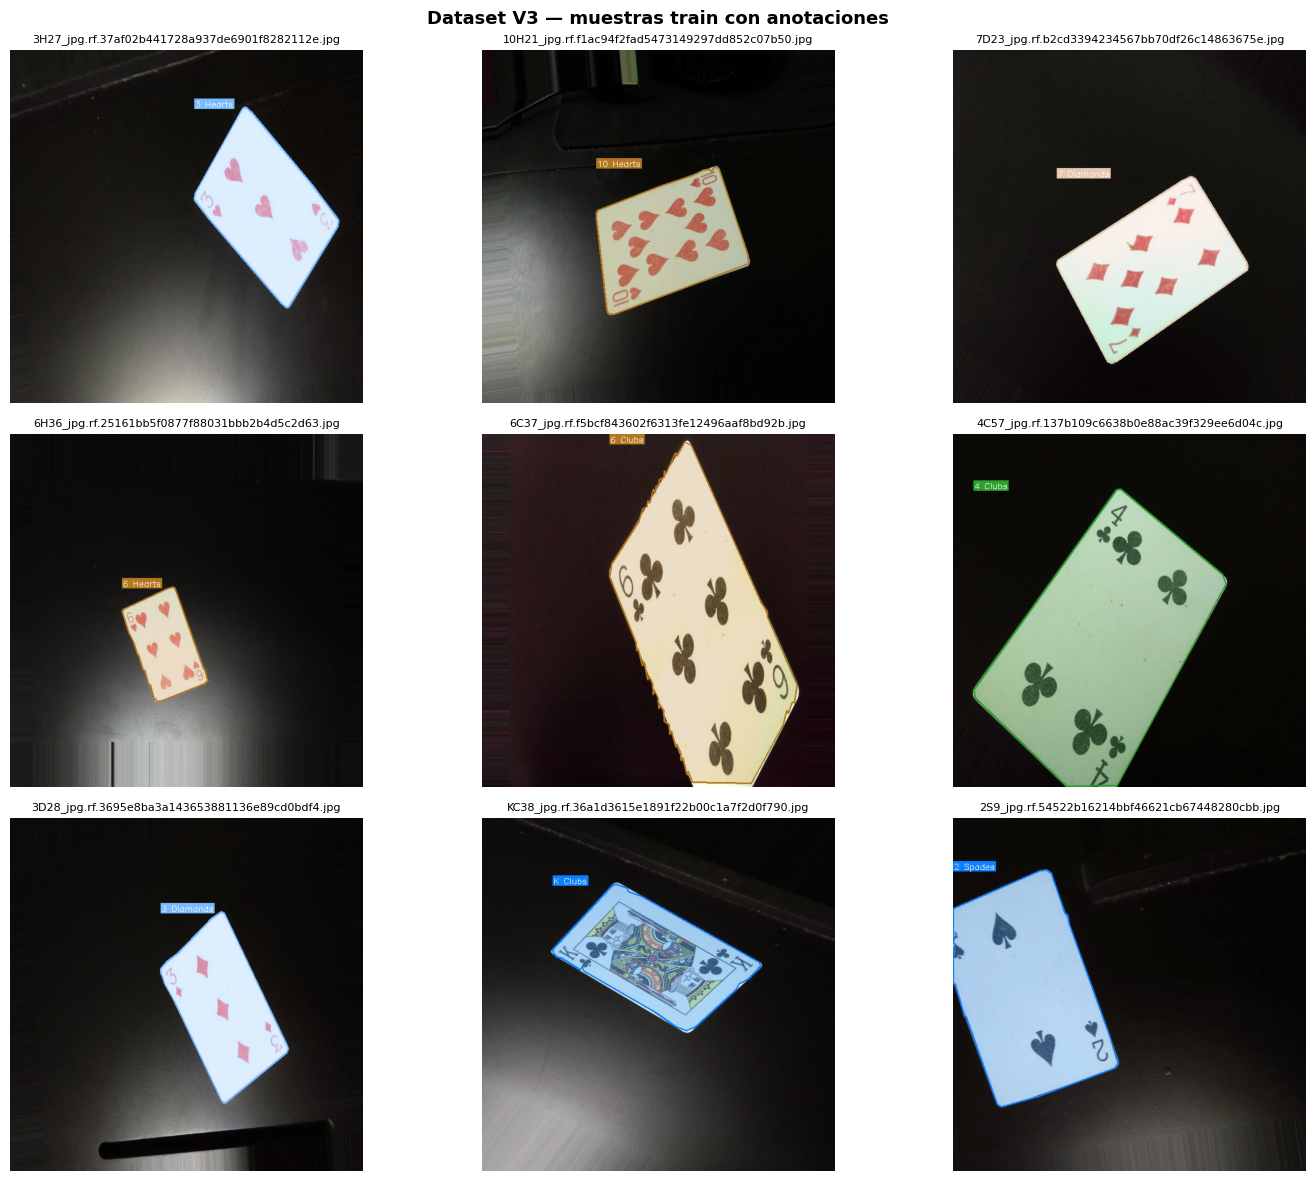

In [6]:
import cv2, random
import numpy as np
import matplotlib.pyplot as plt

random.seed(SEED)
CMAP = plt.cm.get_cmap("tab20", len(names))

def bgr_color(cls_id):
    r, g, b, _ = CMAP(cls_id % 20)
    return (int(b*255), int(g*255), int(r*255))

def draw_sample(img_path: Path, lbl_path: Path):
    img = cv2.imread(str(img_path))
    if img is None: return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    if not lbl_path.exists(): return img
    for ln in lbl_path.read_text(encoding="utf-8").splitlines():
        toks = ln.strip().split()
        if not toks or len(toks) < 7: continue
        cls_id = int(float(toks[0]))
        coords = np.array(list(map(float, toks[1:])), dtype=np.float32).reshape(-1, 2)
        coords[:, 0] *= w; coords[:, 1] *= h
        pts = coords.astype(np.int32)
        color = bgr_color(cls_id)
        if len(pts) >= 3:
            ov = img.copy()
            cv2.fillPoly(ov, [pts], color)
            img = cv2.addWeighted(ov, 0.25, img, 0.75, 0)
            cv2.polylines(img, [pts], True, color, 2)
        x0, y0 = pts.min(axis=0)
        label = names[cls_id] if cls_id < len(names) else f"cls_{cls_id}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        y0c = max(y0, th + 4)
        cv2.rectangle(img, (x0, y0c-th-4), (x0+tw+2, y0c+2), color, -1)
        cv2.putText(img, label, (x0+1, y0c-1), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
    return img

train_img_dir = DATASET_DIR / "train" / "images"
train_imgs    = sorted(train_img_dir.glob("*.*"))
samples       = random.sample(train_imgs, min(9, len(train_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, img_path in zip(axes.flatten(), samples):
    lbl_path = img_path.parent.parent / "labels" / f"{img_path.stem}.txt"
    ann = draw_sample(img_path, lbl_path)
    if ann is not None:
        ax.imshow(ann)
        ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")
plt.suptitle("Dataset V3 — muestras train con anotaciones", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Configurar MLflow + callbacks YOLO

In [7]:
from ultralytics import settings as yolo_settings

# Reactivar MLflow interno de YOLO (puede haber quedado desactivado de sesiones anteriores)
yolo_settings.update({"mlflow": True})

print(f"YOLO mlflow activo  : {yolo_settings.get('mlflow')}")
print(f"MLflow URI          : {os.environ['MLFLOW_TRACKING_URI']}")
print(f"MLflow experiment   : {os.environ['MLFLOW_EXPERIMENT_NAME']}")
print("Todo listo — ejecuta la celda de entrenamiento.")

YOLO mlflow activo  : True
MLflow URI          : http://172.31.71.204:5001
MLflow experiment   : blackjackvai-v3
Todo listo — ejecuta la celda de entrenamiento.


## 7. Entrenamiento con reanudación automática

- Si `last.pt` existe y `RESUME=True` → reanuda desde el último checkpoint
- Si no → inicia desde cero con pesos preentrenados COCO
- Checkpoints cada `SAVE_PERIOD` epochs + `best.pt` y `last.pt` siempre

In [8]:
from ultralytics import YOLO

resuming = RESUME and LAST_PT.exists()

if resuming:
    print(f"Reanudando desde: {LAST_PT}")
    model = YOLO(str(LAST_PT))
else:
    print(f"Iniciando entrenamiento desde cero: {MODEL_BASE}")
    model = YOLO(MODEL_BASE)

train_kwargs = dict(
    data         = str(DATA_YAML),
    task         = "segment",
    epochs       = EPOCHS,
    imgsz        = IMGSZ,
    batch        = BATCH,
    device       = DEVICE,
    workers      = 4,
    seed         = SEED,
    pretrained   = True,
    amp          = True,
    cache        = False,
    cos_lr       = True,
    patience     = PATIENCE,
    save_period  = SAVE_PERIOD,
    plots        = True,
    save         = True,
    project      = str(WORKDIR / "runs"),  # ruta absoluta → YOLO guarda en training_runs/runs/yolo8m_seg_v3
    name         = RUN_NAME,
    exist_ok     = True,
    hsv_h        = 0.02,
    hsv_s        = 0.70,
    hsv_v        = 0.40,
    degrees      = 10.0,
    translate    = 0.10,
    scale        = 0.30,
    shear        = 2.0,
    flipud       = 0.15,
    fliplr       = 0.50,
    mosaic       = 1.0,
    mixup        = 0.15,
    copy_paste   = 0.20,
    close_mosaic = 10,
    overlap_mask = True,
    mask_ratio   = 4,
)

if resuming:
    results = model.train(resume=True)
else:
    results = model.train(**train_kwargs)

RUN_DIR_FINAL = Path(model.trainer.save_dir)
BEST_PT_FINAL = RUN_DIR_FINAL / "weights" / "best.pt"
LAST_PT_FINAL = RUN_DIR_FINAL / "weights" / "last.pt"

print(f"\nEntrenamiento completado.")
print(f"best.pt → {BEST_PT_FINAL}")
print(f"last.pt → {LAST_PT_FINAL}")

Iniciando entrenamiento desde cero: yolov8m-seg.pt
Ultralytics 8.4.45 🚀 Python-3.11.14 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-3/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.15, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo

## 8. Curvas de entrenamiento

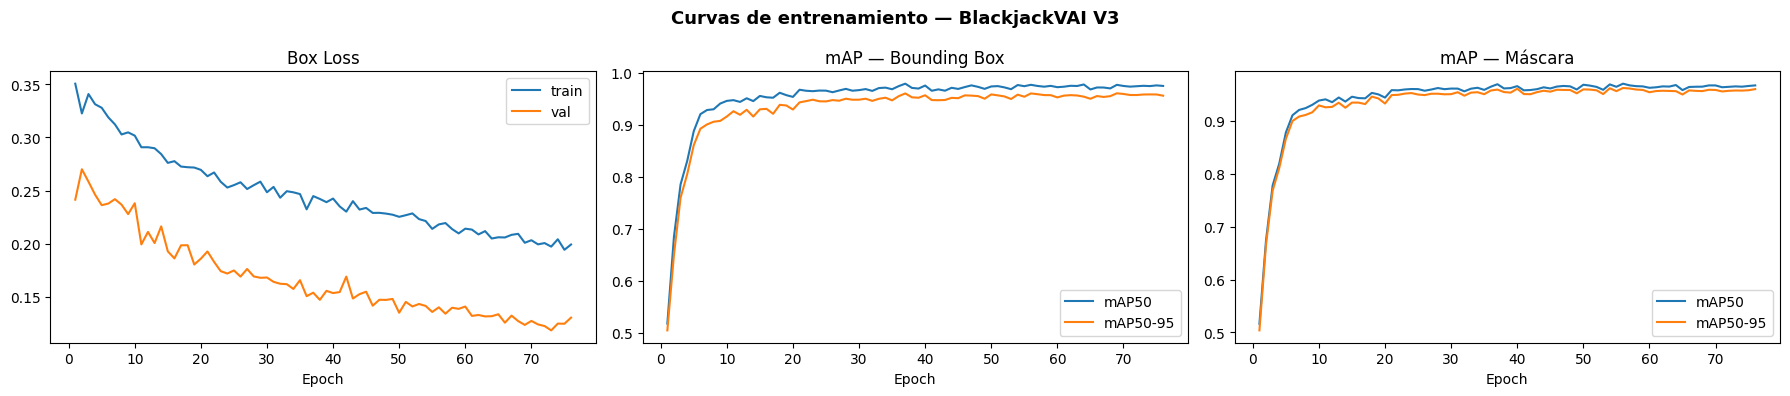

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = RUN_DIR_FINAL / "results.csv"
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Box loss
    for col, lbl in [("train/box_loss", "train"), ("val/box_loss", "val")]:
        if col in df.columns: axes[0].plot(df["epoch"], df[col], label=lbl)
    axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    # mAP Box
    for col, lbl in [("metrics/mAP50(B)", "mAP50"), ("metrics/mAP50-95(B)", "mAP50-95")]:
        if col in df.columns: axes[1].plot(df["epoch"], df[col], label=lbl)
    axes[1].set_title("mAP — Bounding Box"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    # mAP Mask
    for col, lbl in [("metrics/mAP50(M)", "mAP50"), ("metrics/mAP50-95(M)", "mAP50-95")]:
        if col in df.columns: axes[2].plot(df["epoch"], df[col], label=lbl)
    axes[2].set_title("mAP — Máscara"); axes[2].set_xlabel("Epoch"); axes[2].legend()

    plt.suptitle("Curvas de entrenamiento — BlackjackVAI V3", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("results.csv no encontrado — ejecuta la celda de entrenamiento primero.")

## 9. Evaluación cuantitativa (val + test)

In [21]:
import mlflow                                
import re                                  
from ultralytics import YOLO                 
from datetime import datetime                
                                           
def sanitize(key):                         
  return re.sub(r'[^a-zA-Z0-9_\-\. :/]','_', key)                                    
                                     
# ── Evaluación sobre test split             
             
model = YOLO("training_runs/runs/yolo8m_seg_v3/weights/best.pt")                          
                                     
m = model.val(                               
  data="BlackjackVAI-3/data.yaml",       
  split="test",                            
  imgsz=640,
  conf=0.7,                                
  iou=0.45,                              
  plots=True,                        
  save_json=True,                          
)
                                           
print(f"\nmAP50(box) : {m.box.map50:.4f}")                    
print(f"mAP50-95(box) : {m.box.map:.4f}") 
print(f"mAP50(mask):{m.seg.map50:.4f}")                          


print(f"\nmAP50      (box) : {m.box.map50:.4f}")
print(f"mAP50-95   (box) : {m.box.map:.4f}")
print(f"mAP50      (mask): {m.seg.map50:.4f}")
print(f"mAP50-95   (mask): {m.seg.map:.4f}")

# ── Log en MLflow ──────────────────────────────────────────
mlflow.set_tracking_uri("http://172.31.71.204:5001")
mlflow.set_experiment("blackjackvai-v3")

with mlflow.start_run(run_name=f"test_eval_{datetime.now():%Y%m%d_%H%M}"):

  # Métricas principales
  mlflow.log_metrics({
      "test/mAP50_box":     m.box.map50,
      "test/mAP50-95_box":  m.box.map,
      "test/mAP50_mask":    m.seg.map50,
      "test/mAP50-95_mask": m.seg.map,
      "test/precision":     m.box.mp,
      "test/recall":        m.box.mr,
  })

  # Todas las métricas del results_dict sanitizadas
  for k, v in m.results_dict.items():
      try:
          mlflow.log_metric(f"test_{sanitize(k)}", float(v))
      except (TypeError, ValueError):
          pass

  # Modelo y artefactos
  mlflow.log_artifact(
      "training_runs/runs/yolo8m_seg_v3/weights/best.pt",                                                                                           
      artifact_path="model"
  )                                                                                                                                                 
  mlflow.log_artifacts(                                   
      "training_runs/runs/yolo8m_seg_v3/",                                                                                                          
      artifact_path="train_artifacts"
  )                                                                                                                                                 
                                                          
  mlflow.set_tags({                                                                                                                                 
      "stage":    "test_evaluation",
      "dataset":  "BlackjackVAI-V3",                                                                                                                
      "classes":  54,                                                                                                                               
      "backbone": "yolov8m-seg",     
      "best_epoch": 56,                                                                                                                             
  })                                                                                                                                                
                                     
  print("\nLoggeado en MLflow ✓")  

Ultralytics 8.4.45 🚀 Python-3.11.14 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,253,650 parameters, 0 gradients, 104.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1962.3±662.3 MB/s, size: 48.5 KB)
val: Scanning /home/dmore/code/Máster IA/01.-MASTER COURSES/10.- VISIÓN ARTIFICIAL AVANZADA/blackjack-VAI/BlackjackVAI-3/test/labels.cache... 314 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 314/314 219.5Mit/s 0.0s
requirements: Ultralytics requirement ['faster-coco-eval>=1.6.7'] not found, attempting AutoUpdate...
Using Python 3.11.14 environment at: /home/dmore/code/Máster IA/01.-MASTER COURSES/12.- MLOPS Y AI BI/mlops_env/.venv
Resolved 2 packages in 366ms
Prepared 1 package in 93ms
Installed 1 package in 3ms
 + faster-coco-eval==1.7.2

requirements: AutoUpdate success ✅ 0.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

                 Class     Images  Inst

## 10. Grid de predicciones sobre val

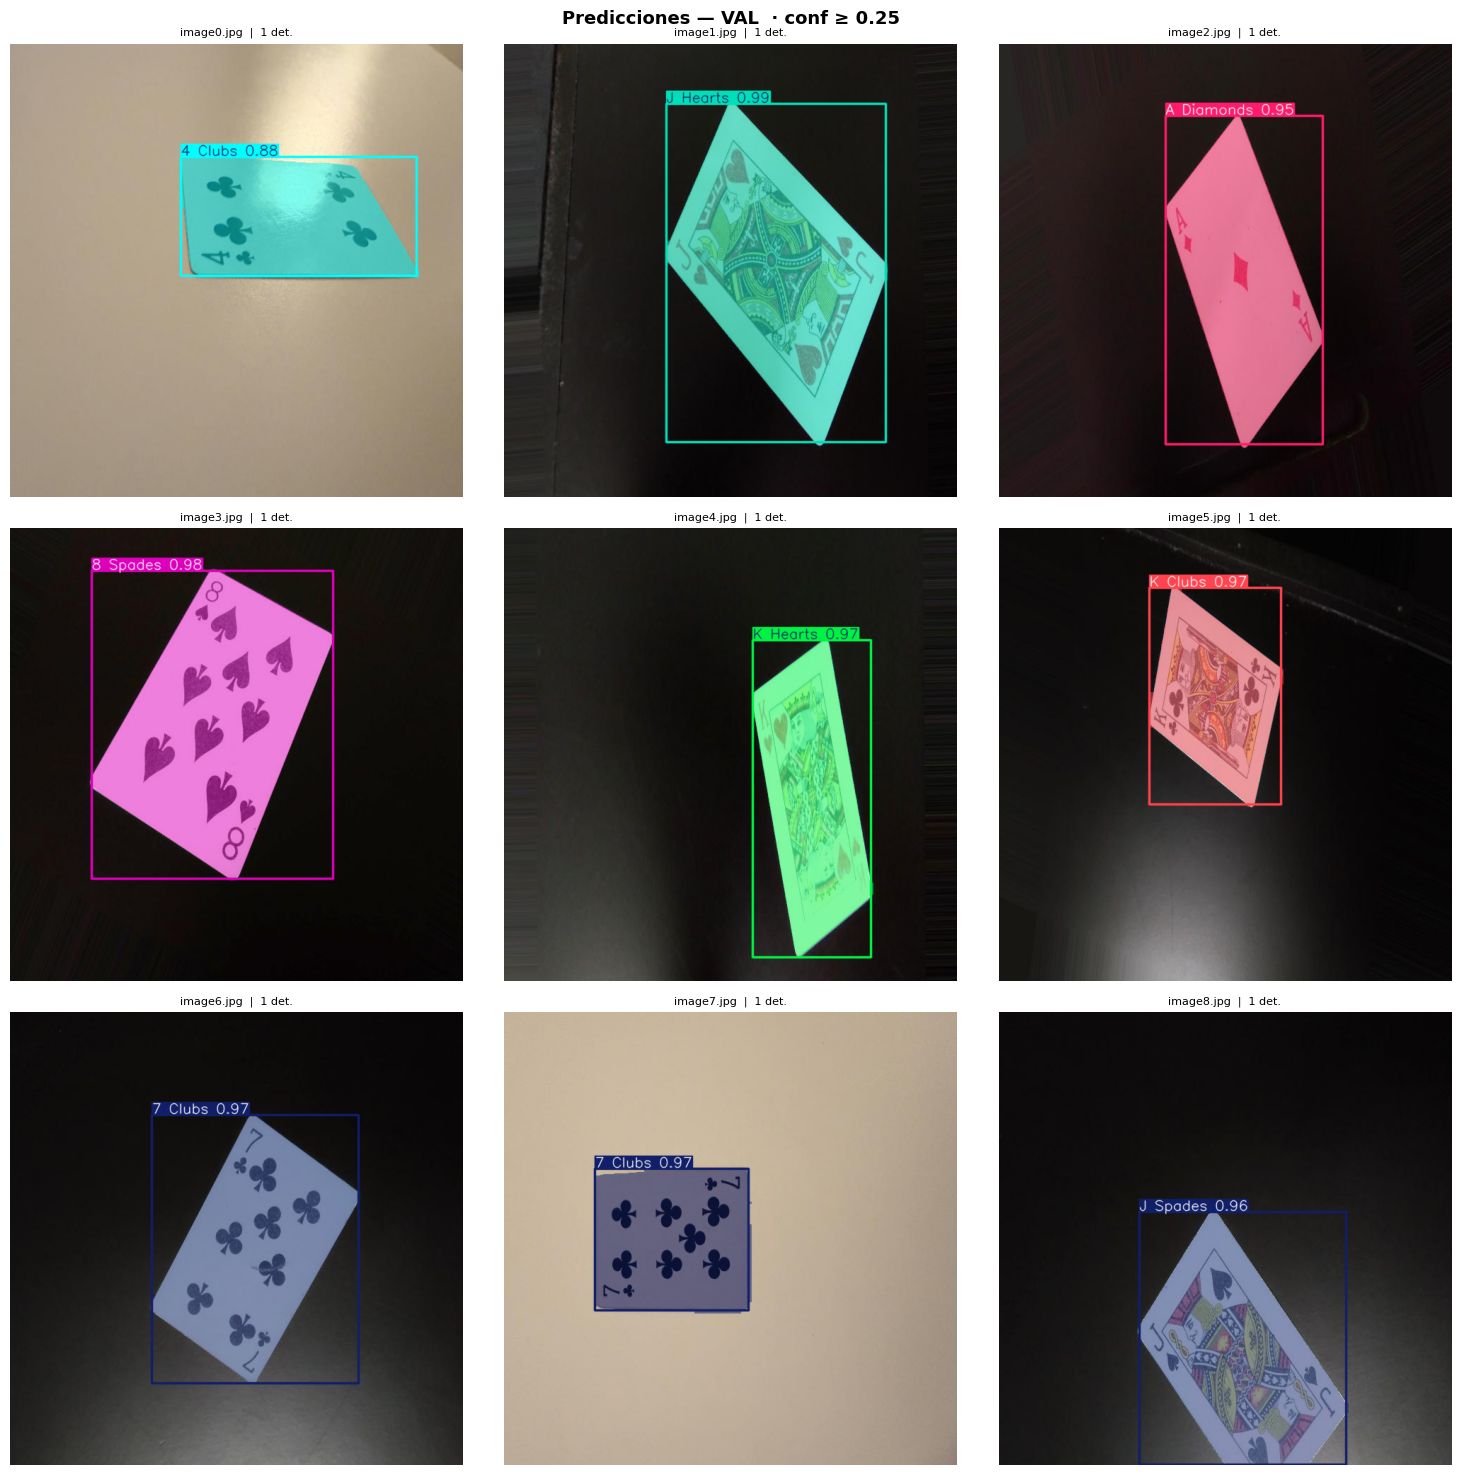

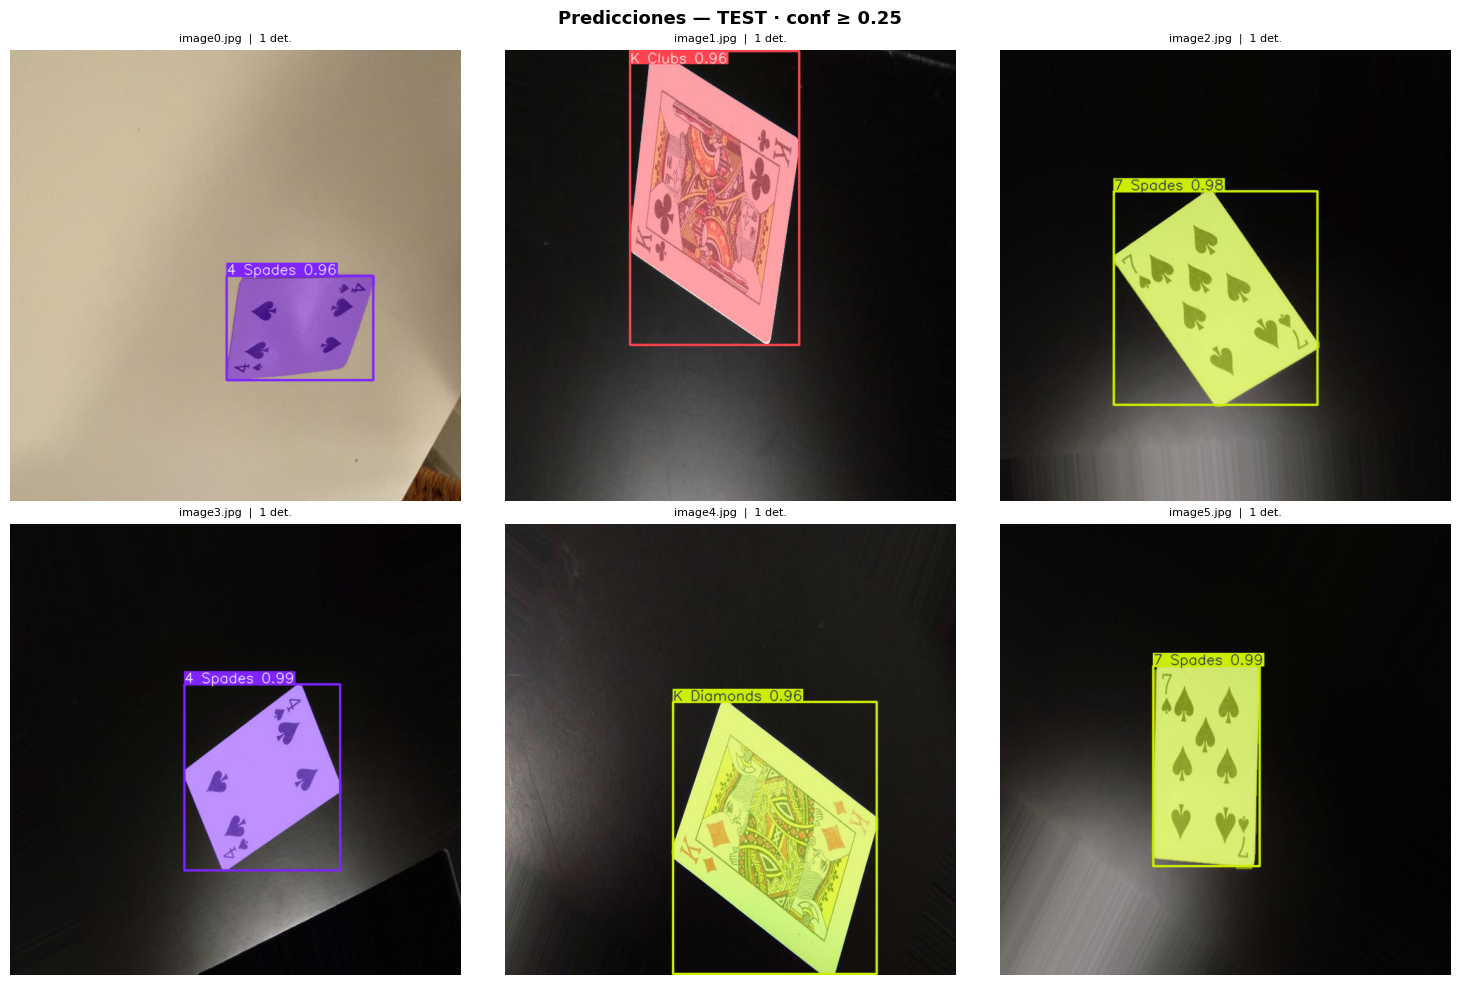

In [22]:
import cv2, random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

random.seed(SEED)
pred_model = YOLO(str(BEST_PT_FINAL))

def pred_grid(img_dir: Path, title: str, n=9, conf=0.25):
    imgs  = [p for p in img_dir.rglob("*.*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    samp  = random.sample(imgs, min(n, len(imgs)))
    preds = pred_model.predict(source=[str(p) for p in samp], imgsz=IMGSZ, conf=conf, verbose=False)
    cols  = 3; rows = (len(preds) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = np.array(axes).flatten()
    for i, res in enumerate(preds):
        ann  = cv2.cvtColor(res.plot(line_width=2), cv2.COLOR_BGR2RGB)
        dets = len(res.boxes) if res.boxes is not None else 0
        axes[i].imshow(ann)
        axes[i].set_title(f"{Path(res.path).name}  |  {dets} det.", fontsize=8)
        axes[i].axis("off")
    for j in range(len(preds), len(axes)): axes[j].axis("off")
    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

pred_grid(DATASET_DIR / "val"  / "images", "Predicciones — VAL  · conf ≥ 0.25", n=9)
pred_grid(DATASET_DIR / "test" / "images", "Predicciones — TEST · conf ≥ 0.25", n=6)

## 11. Exportar modelo final a `models/`

In [ ]:
import shutil
from datetime import datetime

ts = datetime.now().strftime("%Y%m%d_%H%M")
dest = MODELS_DIR / f"best_v3_{ts}.pt"
shutil.copy2(str(BEST_PT_FINAL), str(dest))

# Enlace simbólico 'best.pt' → siempre apunta al último best
link = MODELS_DIR / "best.pt"
if link.exists() or link.is_symlink():
    link.unlink()
link.symlink_to(dest.name)

print(f"Modelo guardado: {dest}")
print(f"Enlace activo  : {link} → {dest.name}")
print("\nContenido de models/:")
for f in sorted(MODELS_DIR.iterdir()):
    size = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f"  {f.name}  ({size:.1f} MB)")

## 12. Test rápido con webcam local

Ejecuta esta celda para ver la detección en tiempo real.  
Pulsa **Q** en la ventana de OpenCV para salir.

In [ ]:
import cv2
from ultralytics import YOLO

WEBCAM_INDEX = 0    # cambia si tienes varias cámaras
CONF_THRESH  = 0.35

webcam_model = YOLO(str(MODELS_DIR / "best.pt"))

cap = cv2.VideoCapture(WEBCAM_INDEX)
if not cap.isOpened():
    raise RuntimeError(f"No se puede abrir la cámara {WEBCAM_INDEX}")

print("Webcam abierta — pulsa Q para salir")
while True:
    ret, frame = cap.read()
    if not ret:
        break
    results = webcam_model.predict(source=frame, imgsz=IMGSZ, conf=CONF_THRESH, verbose=False)
    annotated = results[0].plot(line_width=2)
    cv2.imshow("BlackjackVAI — deteccion", annotated)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Webcam cerrada.")